In [1]:
#import modules 
import pandas as pd
from sklearn.model_selection import RepeatedKFold
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from numpy import mean
from numpy import absolute
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

In [2]:
#Exercise 1
df = pd.read_csv('bank.csv')
df = df.dropna()
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,subscribe
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [11]:
#prepare the data
from sklearn.preprocessing import MinMaxScaler

y = df['subscribe'].map({'no': 0, 'yes': 1})
X = df.drop('subscribe',axis=1) #Select features
X = pd.get_dummies(X, drop_first=True)

#Normalize the data
columns = X.columns #create index with column names (needed for last step)
scaler = MinMaxScaler() #initiate the scaler
X = scaler.fit_transform(X) #scale the data
X = pd.DataFrame(X,columns=columns) #turn back into a dataframe

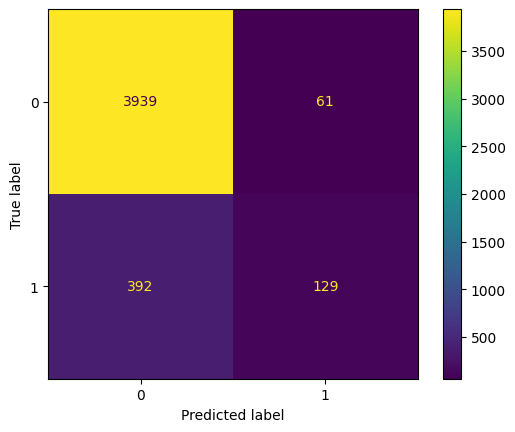

Accuracy: 0.8998009289980093
Precision: 0.6789473684210526
Recall: 0.2476007677543186
F1 Score: 0.3628691983122363


In [12]:
#Predict if someone would subscribe to a term deposit
logreg = LogisticRegression() #define the logistic regression function

y_pred = cross_val_predict(logreg, X, y, cv=5) #make the prediction with 5 folds

cm = confusion_matrix(y, y_pred) #create the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm) #create the graph
disp.plot() #plot the graph
plt.show() #show the graph

#calculate metrics
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)

#print the metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

In [13]:
#Exercise 2
df = pd.read_csv('co2.csv')
df = df.dropna()
df.head()

,Make,Model,VehicleClass,EngineSize(L),Cylinders,Transmission,FuelType,FuelConsumptionCity(L/100km),FuelConsumptionHwy(L/100km),FuelConsumptionComb(L/100km),CO2Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,244


In [14]:
#prediction with all variables
y = df['CO2Emissions(g/km)'] #select Target
X = df.drop(['CO2Emissions(g/km)','Make','Model'],axis=1) #Select features
X = pd.get_dummies(X, drop_first=True)

#predict with linear regression
lm = LinearRegression()
lmscores = cross_val_score(lm, X, y, #these define the type of model, features, and target
                           scoring='neg_mean_absolute_error', #test using mean absolute deviation
                           cv=5) #use cross-validation with 5 folds


lmMAE = mean(absolute(lmscores)) #Calculate the overall mean absolute error
print('the average prediction error with full data is: %.0f' % lmMAE) #Print the result

the average prediction error with full data is: 3
